# UAS Bengkel Koding Data Science
## Project: Customer Churn Prediction

Dataset yang digunakan adalah Sales and Marketing Customer Dataset.

Target prediksi:
- `churn = 0` berarti pelanggan tidak churn
- `churn = 1` berarti pelanggan churn

Notebook ini mengerjakan bagian:
## Poin Penugasan 1 — EDA

In [45]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

import warnings
warnings.filterwarnings("ignore")

# Library untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import sklearn
import joblib

# Setting tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

print("Library berhasil diimport.")
print("Scikit-learn version:", sklearn.__version__)


Library berhasil diimport.
Scikit-learn version: 1.6.1


## Menghubungkan Google Colab dengan Google Drive

Dataset disimpan di Google Drive, sehingga langkah pertama adalah melakukan mount Drive.

In [46]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## Load Dataset

Silakan sesuaikan `DATA_PATH` dengan lokasi file dataset di Google Drive.

Contoh:
- `/content/drive/MyDrive/dataset/sales_and_marketing.csv`
- `/content/drive/MyDrive/UAS/sales_marketing.csv`
> Tambahkan blockquote



In [47]:
# ============================================================
# LOAD DATASET
# ============================================================

# GANTI PATH INI SESUAI LOKASI DATASET KAMU DI GOOGLE DRIVE
DATA_PATH = "/content/drive/MyDrive/UAS_BENGKOD/sales_and_marketing.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dimuat.")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat.
Jumlah baris: 15000
Jumlah kolom: 30


## Pemeriksaan Awal Dataset

Pada tahap ini dilakukan pengecekan awal struktur dataset, seperti ukuran data, nama kolom, dan tipe data awal.

In [48]:
# ============================================================
# PEMERIKSAAN AWAL DATASET
# ============================================================

print("Ukuran dataset:")
display(df.shape)

print("\nDaftar kolom:")
display(df.columns.tolist())

print("\nTipe data setiap kolom:")
display(df.dtypes)

Ukuran dataset:


(15000, 30)


Daftar kolom:


['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'signup_date',
 'last_purchase_date',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'coupon_code',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn']


Tipe data setiap kolom:


,0
customer_id,int64
gender,object
age,float64
country,object
city,object
signup_date,object
last_purchase_date,object
acquisition_channel,object
device_type,object
subscription_type,object


## Standarisasi Nama Kolom

Nama kolom dibuat lowercase dan spasi diganti underscore agar lebih mudah digunakan dalam proses analisis dan modeling.

# ============================================================
# STANDARISASI NAMA KOLOM
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Nama kolom setelah distandarisasi:")
display(df.columns.tolist())

In [49]:
# ============================================================
# STANDARISASI NAMA KOLOM
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Nama kolom setelah distandarisasi:")
display(df.columns.tolist())

Nama kolom setelah distandarisasi:


['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'signup_date',
 'last_purchase_date',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'coupon_code',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn']

## Konversi Kolom Tanggal

Kolom `signup_date` dan `last_purchase_date` dikonversi menjadi format datetime apabila kolom tersebut tersedia di dataset.

In [50]:
# ============================================================
# KONVERSI KOLOM TANGGAL
# ============================================================

date_columns = ["signup_date", "last_purchase_date"]

converted_cols = []

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        converted_cols.append(col)

print("Kolom tanggal yang berhasil dikonversi:")
display(converted_cols)

print("\nTipe data setelah konversi:")
if len(converted_cols) > 0:
    display(df[converted_cols].dtypes)
else:
    print("Tidak ada kolom tanggal yang ditemukan.")

Kolom tanggal yang berhasil dikonversi:


['signup_date', 'last_purchase_date']


Tipe data setelah konversi:


,0
signup_date,datetime64[ns]
last_purchase_date,datetime64[ns]


# Poin Penugasan 1.1 — Menampilkan 5 Baris Pertama Dataset

Bagian ini digunakan untuk melihat contoh isi data pada 5 baris pertama.

In [51]:
# ============================================================
# POIN 1.1 - MENAMPILKAN 5 BARIS PERTAMA DATASET
# ============================================================

display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10,2024-12-31,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,NEW20,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,NEW20,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23,2024-04-28,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,NaN,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,NaN,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21,2024-04-07,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,NaN,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


# Poin Penugasan 1.1 — Menampilkan Informasi Dataset

Bagian ini digunakan untuk melihat jumlah data, tipe data setiap kolom, dan jumlah nilai non-null.

In [52]:
# ============================================================
# POIN 1.1 - INFORMASI DATASET
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 15000 non-null  int64         
 1   gender                      14262 non-null  object        
 2   age                         13800 non-null  float64       
 3   country                     15000 non-null  object        
 4   city                        15000 non-null  object        
 5   signup_date                 15000 non-null  datetime64[ns]
 6   last_purchase_date          15000 non-null  datetime64[ns]
 7   acquisition_channel         15000 non-null  object        
 8   device_type                 15000 non-null  object        
 9   subscription_type           15000 non-null  object        
 10  is_premium_user             15000 non-null  int64         
 11  total_visits                15000 non-null  int64     

# Poin Penugasan 1.1 — Statistik Deskriptif

Bagian ini menampilkan statistik deskriptif untuk kolom numerik dan kategorikal.

In [53]:
# ============================================================
# POIN 1.1 - STATISTIK DESKRIPTIF KOLOM NUMERIK
# ============================================================

display(df.describe())

,customer_id,age,signup_date,last_purchase_date,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,2023-05-15 21:46:04.800000,2024-02-04 16:45:18.720000256,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
min,10001.000000,-4.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,2022-09-04 00:00:00,2023-07-17 00:00:00,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,2023-05-19 00:00:00,2024-02-07 00:00:00,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,2024-01-22 00:00:00,2024-08-25 00:00:00,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,2024-09-26 00:00:00,2025-03-10 00:00:00,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000
std,4330.271354,10.334384,NaN,NaN,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192


In [54]:
# ============================================================
# POIN 1.1 - STATISTIK DESKRIPTIF SEMUA KOLOM
# ============================================================

display(df.describe(include="all"))

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,8867,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,NaN,NaN,5,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,NaN,NaN,Organic,Tablet,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,REF10,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,NaN,NaN,3055,5043,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2995,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,2023-05-15 21:46:04.800000,2024-02-04 16:45:18.720000256,NaN,NaN,NaN,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,NaN,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
min,10001.000000,NaN,-4.000000,NaN,NaN,2022-01-01 00:00:00,2023-01-01 00:00:00,NaN,NaN,NaN,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,2022-09-04 00:00:00,2023-07-17 00:00:00,NaN,NaN,NaN,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,NaN,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,2023-05-19 00:00:00,2024-02-07 00:00:00,NaN,NaN,NaN,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,NaN,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,2024-01-22 00:00:00,2024-08-25 00:00:00,NaN,NaN,NaN,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,NaN,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,NaN,95.000000,NaN,NaN,2024-09-26 00:00:00,2025-03-10 00:00:00,NaN,NaN,NaN,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,NaN,9.000000,1.000000,11.000000,NaN,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


# Poin Penugasan 1.2 — Menghitung Persentase Missing Value

Bagian ini menghitung jumlah dan persentase nilai kosong pada setiap kolom.

In [55]:
# ============================================================
# POIN 1.2 - MENGHITUNG MISSING VALUE
# ============================================================

missing_value = df.isnull().sum()
missing_percentage = (missing_value / len(df)) * 100

missing_df = pd.DataFrame({
    "Jumlah Missing Value": missing_value,
    "Persentase Missing Value (%)": missing_percentage
})

missing_df = missing_df.sort_values(by="Persentase Missing Value (%)", ascending=False)

display(missing_df)

,Jumlah Missing Value,Persentase Missing Value (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000
customer_id,0,0.000000
last_purchase_date,0,0.000000
acquisition_channel,0,0.000000
device_type,0,0.000000
subscription_type,0,0.000000


# Poin Penugasan 1.2 — Visualisasi Missing Value

Bagian ini menampilkan persentase missing value dalam bentuk diagram batang.

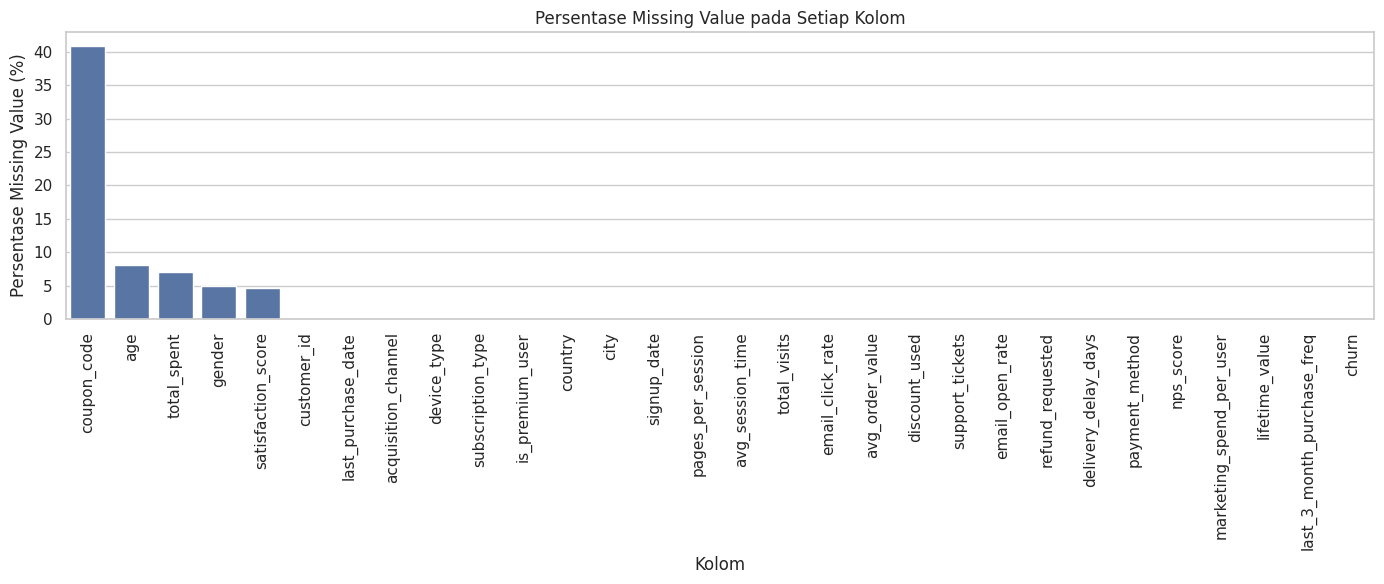

In [56]:
# ============================================================
# POIN 1.2 - VISUALISASI MISSING VALUE
# ============================================================

plt.figure(figsize=(14, 6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Persentase Missing Value (%)"]
)

plt.xticks(rotation=90)
plt.title("Persentase Missing Value pada Setiap Kolom")
plt.xlabel("Kolom")
plt.ylabel("Persentase Missing Value (%)")
plt.tight_layout()
plt.show()

# Poin Penugasan 1.3 — Distribusi Variabel Target Churn

Bagian ini digunakan untuk mengetahui keseimbangan kelas target `churn`.

- `0` = pelanggan tidak churn
- `1` = pelanggan churn

In [57]:
# ============================================================
# POIN 1.3 - CEK KOLOM TARGET
# ============================================================

target_col = "churn"

if target_col not in df.columns:
    raise ValueError("Kolom target 'churn' tidak ditemukan. Periksa kembali nama kolom dataset.")

print("Kolom target ditemukan:", target_col)

display(df[target_col].value_counts())
display(df[target_col].value_counts(normalize=True) * 100)

Kolom target ditemukan: churn


,count
churn,
0,12702
1,2298


,proportion
churn,
0,84.68
1,15.32


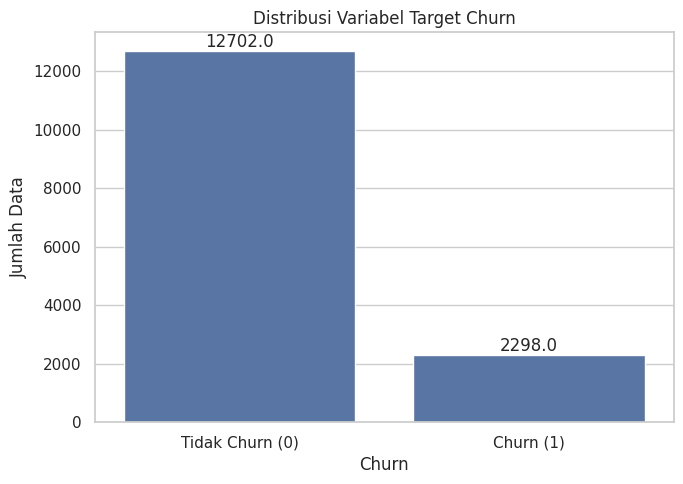

In [58]:
# ============================================================
# POIN 1.3 - VISUALISASI DISTRIBUSI TARGET CHURN
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=target_col
)

plt.title("Distribusi Variabel Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Data")
plt.xticks([0, 1], ["Tidak Churn (0)", "Churn (1)"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# POIN 1.3 - PERSENTASE DISTRIBUSI TARGET CHURN
# ============================================================

churn_distribution = df[target_col].value_counts().reset_index()
churn_distribution.columns = ["Churn", "Jumlah"]

churn_distribution["Persentase (%)"] = (
    churn_distribution["Jumlah"] / churn_distribution["Jumlah"].sum()
) * 100

display(churn_distribution)

,Churn,Jumlah,Persentase (%)
0,0,12702,84.68
1,1,2298,15.32


# Poin Penugasan 1.4 — Heatmap Korelasi Fitur Numerik

Bagian ini membuat heatmap korelasi antar fitur numerik untuk melihat hubungan antar variabel, terutama variabel yang berpotensi memengaruhi churn pelanggan.

In [60]:
# ============================================================
# POIN 1.4 - SELEKSI FITUR NUMERIK
# ============================================================

numeric_df = df.select_dtypes(include=["int64", "float64", "int32", "float32"])

print("Jumlah fitur numerik:", numeric_df.shape[1])
display(numeric_df.head())

Jumlah fitur numerik: 20


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,0,0,3,3.0,10,27.56,915.310827,14,0
1,10002,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,5,0,3,3.0,7,15.15,2079.960938,11,0
2,10003,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,1,0,2,5.0,6,13.51,1379.150885,9,0
3,10004,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,0,0,2,4.0,6,25.65,774.652684,7,0
4,10005,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,2,1,4,3.0,1,12.39,87.680409,11,0


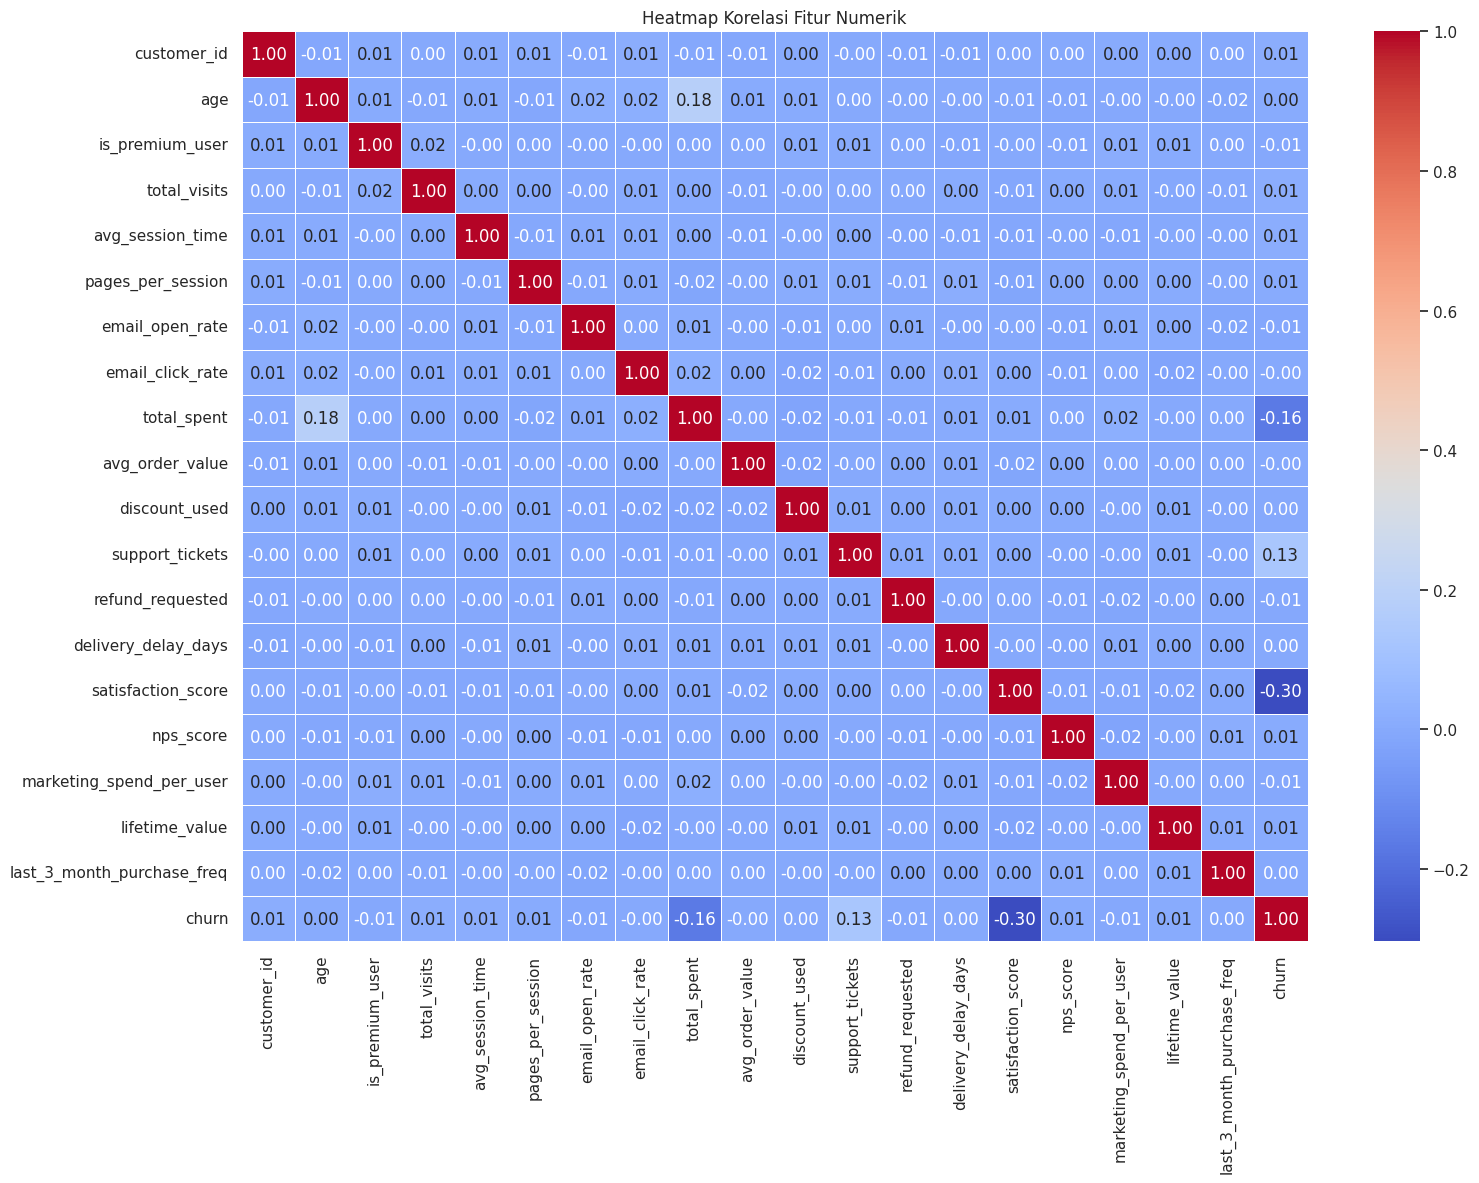

In [61]:
# ============================================================
# POIN 1.4 - HEATMAP KORELASI FITUR NUMERIK
# ============================================================

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

,Fitur,Korelasi terhadap Churn
0,churn,1.000000
1,support_tickets,0.127910
2,total_visits,0.013212
3,customer_id,0.012208
4,avg_session_time,0.012198
5,lifetime_value,0.006250
6,pages_per_session,0.005871
7,nps_score,0.005749
8,age,0.004506
9,delivery_delay_days,0.001603


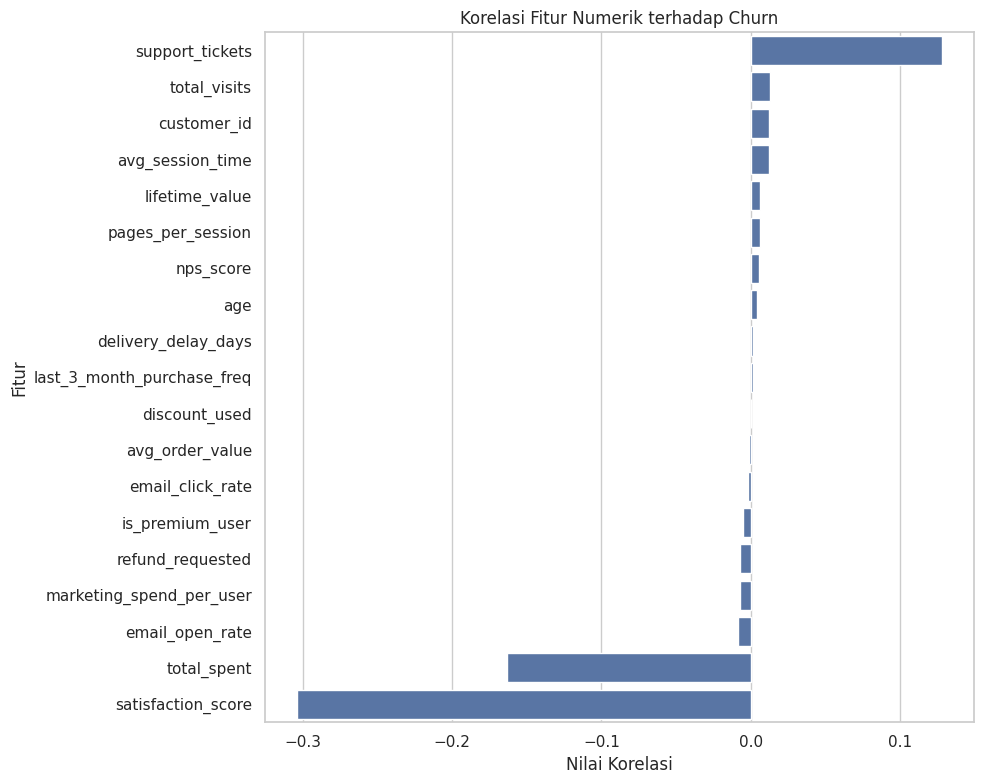

In [62]:
# ============================================================
# POIN 1.4 - KORELASI FITUR NUMERIK TERHADAP TARGET CHURN
# ============================================================

if target_col in numeric_df.columns:
    churn_corr = corr_matrix[target_col].sort_values(ascending=False)

    churn_corr_df = pd.DataFrame({
        "Fitur": churn_corr.index,
        "Korelasi terhadap Churn": churn_corr.values
    })

    display(churn_corr_df)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=churn_corr_df[churn_corr_df["Fitur"] != target_col],
        x="Korelasi terhadap Churn",
        y="Fitur"
    )

    plt.title("Korelasi Fitur Numerik terhadap Churn")
    plt.xlabel("Nilai Korelasi")
    plt.ylabel("Fitur")
    plt.tight_layout()
    plt.show()

else:
    print("Kolom churn tidak termasuk fitur numerik, korelasi terhadap churn tidak dapat dihitung.")

# Kesimpulan Sementara EDA

Berdasarkan EDA yang telah dilakukan, bagian yang sudah diselesaikan adalah:

1. Menampilkan 5 baris pertama dataset.
2. Menampilkan informasi dataset.
3. Menampilkan statistik deskriptif.
4. Menghitung persentase missing value.
5. Memvisualisasikan missing value dengan diagram batang.
6. Memvisualisasikan distribusi target `churn`.
7. Membuat heatmap korelasi fitur numerik.
8. Melihat korelasi fitur numerik terhadap target `churn`.

Tahap berikutnya setelah EDA adalah masuk ke bagian:
## Poin Penugasan 2 — Direct Modeling

# Poin Penugasan 2 — Modeling

Bagian ini melanjutkan hasil EDA yang sudah dibuat sebelumnya. Pada tahap ini model mulai dibangun untuk memprediksi nilai `churn`.

Sesuai arahan soal, modeling dikerjakan melalui dua skenario awal:

## 2.1 Direct Modeling
Model dilatih sebagai baseline awal tanpa preprocessing lengkap dan tanpa hyperparameter tuning. Pada tahap ini fitur target ditetapkan terlebih dahulu, lalu data dibagi menjadi data latih dan data uji. Tiga model yang digunakan adalah model konvensional, ensemble bagging, dan ensemble voting.

## 2.2 Modeling Dengan Preprocessing
Model dilatih ulang menggunakan data yang sudah dibersihkan. Tahap ini mencakup penanganan missing value, duplikasi, outlier, encoding fitur kategorikal, scaling setelah data splitting, serta penyesuaian fitur yang kurang relevan.

Catatan: pada bagian tujuan soal terdapat kalimat tentang biaya iklan TV, Radio, Social Media, dan volume penjualan. Namun struktur dataset yang digunakan pada soal ini memiliki target `churn`, sehingga proses modeling tetap difokuskan pada prediksi customer churn.


## Fungsi Evaluasi Model

Fungsi ini digunakan agar hasil evaluasi setiap model memiliki format yang sama, baik pada skenario direct modeling maupun modeling dengan preprocessing.


In [63]:
# ============================================================
# FUNGSI EVALUASI MODEL
# ============================================================

evaluation_results = []

def evaluate_classification_model(model_name, scenario_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    result = {
        "Skenario": scenario_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    evaluation_results.append(result)

    print(f"Hasil Evaluasi - {scenario_name} - {model_name}")
    print("=" * 70)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Tidak Churn (0)", "Churn (1)"],
        yticklabels=["Tidak Churn (0)", "Churn (1)"]
    )
    plt.title(f"Confusion Matrix - {model_name}\n{sccenario_name if False else scenario_name}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.show()

    return result


# 2.1 Direct Modeling

Unit kompetensi pada bagian ini adalah membangun model dasar dan menghasilkan prediksi awal. Skenario ini digunakan sebagai gambaran awal performa model sebelum dilakukan preprocessing lengkap.

Pada tahap ini dilakukan:
1. Menetapkan `y` sebagai kolom `churn`.
2. Menetapkan `X` sebagai seluruh kolom selain `churn`.
3. Melakukan train-test split.
4. Memilih tiga model, yaitu Logistic Regression, Random Forest, dan Voting Classifier.
5. Melatih model tanpa hyperparameter tuning.
6. Mengevaluasi model menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.


## 2.1.1 Menetapkan Variabel Target dan Fitur Prediktor

Target yang digunakan adalah `churn`, sedangkan fitur prediktor diambil dari seluruh kolom lain pada dataset.


In [64]:
# ============================================================
# POIN 2.1.1 - MENETAPKAN TARGET y DAN FITUR X
# ============================================================

df_direct = df.copy()

target_col = "churn"

if target_col not in df_direct.columns:
    raise ValueError("Kolom target 'churn' tidak ditemukan. Periksa kembali nama kolom dataset.")

X_direct_raw = df_direct.drop(columns=[target_col])
y_direct = df_direct[target_col]

print("Ukuran X_direct_raw:", X_direct_raw.shape)
print("Ukuran y_direct    :", y_direct.shape)

print("\nDistribusi target:")
display(y_direct.value_counts())
display(y_direct.value_counts(normalize=True) * 100)


Ukuran X_direct_raw: (15000, 29)
Ukuran y_direct    : (15000,)

Distribusi target:


,count
churn,
0,12702
1,2298


,proportion
churn,
0,84.68
1,15.32


## 2.1.2 Menyesuaikan Data Direct Modeling agar Dapat Dibaca Model

Pada direct modeling, fitur tetap ditetapkan dari seluruh kolom selain `churn`. Namun model scikit-learn tidak dapat membaca data bertipe teks dan tanggal secara langsung. Oleh karena itu, untuk baseline awal ini model hanya menggunakan fitur numerik yang sudah tersedia, tanpa encoding, tanpa scaling, tanpa outlier handling, dan tanpa hyperparameter tuning.

Fitur kategorikal dan tanggal akan digunakan secara lebih lengkap pada skenario berikutnya, yaitu modeling dengan preprocessing.


In [65]:
# ============================================================
# POIN 2.1.2 - DATA DIRECT MODELING
# ============================================================

X_direct = X_direct_raw.select_dtypes(include=["int64", "float64", "int32", "float32"]).copy()

print("Jumlah fitur awal sebelum seleksi teknis:", X_direct_raw.shape[1])
print("Jumlah fitur numerik yang digunakan pada direct modeling:", X_direct.shape[1])

print("\nFitur numerik yang digunakan:")
display(X_direct.columns.tolist())

# Penyesuaian teknis sederhana agar model tidak error jika ada nilai kosong pada fitur numerik
# Pada direct modeling ini tidak dilakukan encoding, scaling, outlier handling, maupun tuning.
X_direct = X_direct.replace([np.inf, -np.inf], np.nan)
X_direct = X_direct.fillna(X_direct.median(numeric_only=True))

print("\nJumlah missing value setelah penyesuaian teknis:", X_direct.isnull().sum().sum())


Jumlah fitur awal sebelum seleksi teknis: 29
Jumlah fitur numerik yang digunakan pada direct modeling: 19

Fitur numerik yang digunakan:


['customer_id',
 'age',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq']


Jumlah missing value setelah penyesuaian teknis: 0


## 2.1.3 Train-Test Split

Data dibagi menjadi data latih dan data uji dengan proporsi 80:20. Proporsi ini akan digunakan kembali pada skenario modeling dengan preprocessing agar hasil perbandingan lebih seimbang.


In [66]:
# ============================================================
# POIN 2.1.3 - TRAIN TEST SPLIT DIRECT MODELING
# ============================================================

X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct,
    y_direct,
    test_size=0.2,
    random_state=42,
    stratify=y_direct
)

print("Ukuran X_train_direct:", X_train_direct.shape)
print("Ukuran X_test_direct :", X_test_direct.shape)
print("Ukuran y_train_direct:", y_train_direct.shape)
print("Ukuran y_test_direct :", y_test_direct.shape)

print("\nDistribusi target pada data latih:")
display(y_train_direct.value_counts(normalize=True) * 100)

print("\nDistribusi target pada data uji:")
display(y_test_direct.value_counts(normalize=True) * 100)


Ukuran X_train_direct: (12000, 19)
Ukuran X_test_direct : (3000, 19)
Ukuran y_train_direct: (12000,)
Ukuran y_test_direct : (3000,)

Distribusi target pada data latih:


,proportion
churn,
0,84.683333
1,15.316667



Distribusi target pada data uji:


,proportion
churn,
0,84.666667
1,15.333333


## 2.1.4 Menentukan Tiga Model Direct Modeling

Tiga model dipilih untuk mewakili tiga kategori:
- Model konvensional: Logistic Regression
- Ensemble bagging: Random Forest
- Ensemble voting: Voting Classifier


In [67]:
# ============================================================
# POIN 2.1.4 - MENENTUKAN MODEL DIRECT
# ============================================================

direct_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Voting Classifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=42)),
            ("knn", KNeighborsClassifier(n_neighbors=5)),
            ("nb", GaussianNB())
        ],
        voting="hard"
    )
}

print("Model yang digunakan pada direct modeling:")
for model_name in direct_models.keys():
    print("-", model_name)


Model yang digunakan pada direct modeling:
- Logistic Regression
- Random Forest
- Voting Classifier


## 2.1.5 Melatih dan Mengevaluasi Model Direct

Ketiga model dilatih menggunakan data direct modeling, kemudian dievaluasi menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.



################################################################################
Training Model Direct: Logistic Regression
################################################################################
Hasil Evaluasi - Direct Modeling - Logistic Regression
Accuracy : 0.8477
Precision: 0.5109
Recall   : 0.1522
F1-Score : 0.2345

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2540
           1       0.51      0.15      0.23       460

    accuracy                           0.85      3000
   macro avg       0.69      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



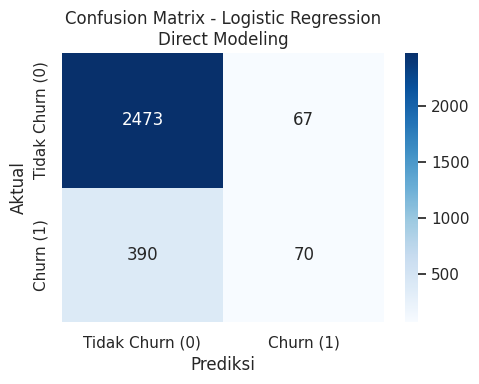


################################################################################
Training Model Direct: Random Forest
################################################################################
Hasil Evaluasi - Direct Modeling - Random Forest
Accuracy : 0.8553
Precision: 0.5365
Recall   : 0.4152
F1-Score : 0.4681

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2540
           1       0.54      0.42      0.47       460

    accuracy                           0.86      3000
   macro avg       0.72      0.68      0.69      3000
weighted avg       0.84      0.86      0.85      3000



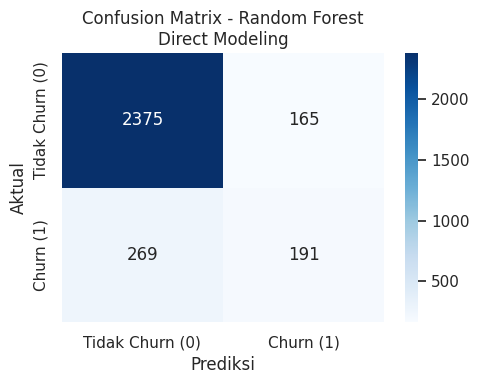


################################################################################
Training Model Direct: Voting Classifier
################################################################################
Hasil Evaluasi - Direct Modeling - Voting Classifier
Accuracy : 0.85
Precision: 0.5439
Recall   : 0.1348
F1-Score : 0.216

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.54      0.13      0.22       460

    accuracy                           0.85      3000
   macro avg       0.70      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



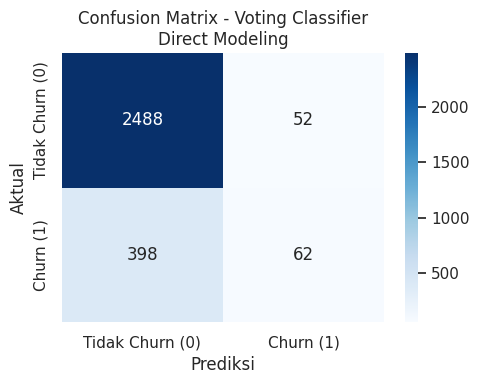

In [68]:
# ============================================================
# POIN 2.1.5 - TRAINING DAN EVALUASI DIRECT MODELING
# ============================================================

direct_predictions = {}

for model_name, model in direct_models.items():
    print("\n" + "#" * 80)
    print(f"Training Model Direct: {model_name}")
    print("#" * 80)

    model.fit(X_train_direct, y_train_direct)
    y_pred_direct = model.predict(X_test_direct)

    direct_predictions[model_name] = y_pred_direct

    evaluate_classification_model(
        model_name=model_name,
        scenario_name="Direct Modeling",
        y_true=y_test_direct,
        y_pred=y_pred_direct
    )


## 2.1.6 Ringkasan Hasil Direct Modeling

Bagian ini menampilkan ringkasan hasil evaluasi dari tiga model pada skenario direct modeling.


In [69]:
# ============================================================
# POIN 2.1.6 - RINGKASAN HASIL DIRECT MODELING
# ============================================================

direct_results_df = pd.DataFrame(evaluation_results)
direct_results_df = direct_results_df[direct_results_df["Skenario"] == "Direct Modeling"]

display(direct_results_df.sort_values(by="F1-Score", ascending=False))


,Skenario,Model,Accuracy,Precision,Recall,F1-Score
1,Direct Modeling,Random Forest,0.855333,0.536517,0.415217,0.468137
0,Direct Modeling,Logistic Regression,0.847667,0.510949,0.152174,0.234506
2,Direct Modeling,Voting Classifier,0.850000,0.543860,0.134783,0.216028


# 2.2 Modeling Dengan Preprocessing

Pada tahap ini model dilatih kembali menggunakan data yang sudah dibersihkan. Proses preprocessing dilakukan agar data lebih siap digunakan untuk modeling dan agar fitur kategorikal dapat ikut digunakan.

Tahapan pada bagian ini meliputi:
1. Penanganan missing value, duplikasi, dan outlier.
2. Encoding fitur kategorikal.
3. Scaling fitur numerik setelah data splitting.
4. Penghapusan atau penyesuaian fitur yang dianggap tidak relevan.
5. Menetapkan kembali fitur prediktor dan target setelah preprocessing.
6. Melakukan train-test split dengan proporsi yang sama seperti direct modeling.
7. Melatih kembali tiga model yang sama tanpa hyperparameter tuning.
8. Mengevaluasi model menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.


## 2.2.1 Membuat Salinan Dataset dan Menangani Duplikasi

Dataset disalin terlebih dahulu agar data hasil EDA tetap aman. Setelah itu data duplikat dicek dan dihapus apabila ditemukan.


In [70]:
# ============================================================
# POIN 2.2.1 - SALIN DATASET DAN HAPUS DUPLIKASI
# ============================================================

df_prep = df.copy()

print("Ukuran dataset sebelum preprocessing:", df_prep.shape)

duplicate_count = df_prep.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)

df_prep = df_prep.drop_duplicates()

print("Ukuran dataset setelah duplikasi dihapus:", df_prep.shape)


Ukuran dataset sebelum preprocessing: (15000, 30)
Jumlah data duplikat: 0
Ukuran dataset setelah duplikasi dihapus: (15000, 30)


## 2.2.2 Penghapusan dan Penyesuaian Fitur Tidak Relevan

Beberapa fitur tidak digunakan secara langsung karena kurang tepat untuk modeling.

Penyesuaian yang dilakukan:
- `customer_id` dihapus karena hanya berfungsi sebagai ID unik.
- `coupon_code` diubah menjadi fitur `has_coupon_code`.
- `signup_date` dan `last_purchase_date` diubah menjadi fitur numerik berbasis waktu.
- Kolom tanggal mentah dihapus setelah fitur baru dibuat.


In [71]:
# ============================================================
# POIN 2.2.2 - PENYESUAIAN FITUR TIDAK RELEVAN
# ============================================================

target_col = "churn"

if target_col not in df_prep.columns:
    raise ValueError("Kolom target 'churn' tidak ditemukan. Periksa kembali nama kolom dataset.")

# Fitur baru dari coupon_code
if "coupon_code" in df_prep.columns:
    df_prep["has_coupon_code"] = df_prep["coupon_code"].notna().astype(int)

# Konversi kolom tanggal
if "signup_date" in df_prep.columns:
    df_prep["signup_date"] = pd.to_datetime(df_prep["signup_date"], errors="coerce")

if "last_purchase_date" in df_prep.columns:
    df_prep["last_purchase_date"] = pd.to_datetime(df_prep["last_purchase_date"], errors="coerce")

# Feature engineering dari kolom tanggal
if "signup_date" in df_prep.columns and "last_purchase_date" in df_prep.columns:
    df_prep["customer_tenure_days"] = (
        df_prep["last_purchase_date"] - df_prep["signup_date"]
    ).dt.days

    reference_date = df_prep["last_purchase_date"].max()

    df_prep["days_since_last_purchase"] = (
        reference_date - df_prep["last_purchase_date"]
    ).dt.days

# Daftar kolom yang dihapus
drop_columns = []

if "customer_id" in df_prep.columns:
    drop_columns.append("customer_id")

if "coupon_code" in df_prep.columns:
    drop_columns.append("coupon_code")

for col in ["signup_date", "last_purchase_date"]:
    if col in df_prep.columns:
        drop_columns.append(col)

df_prep = df_prep.drop(columns=drop_columns)

print("Kolom yang dihapus:")
print(drop_columns)

print("\nUkuran dataset setelah penyesuaian fitur:", df_prep.shape)

print("\nDaftar kolom setelah penyesuaian:")
display(df_prep.columns.tolist())


Kolom yang dihapus:
['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date']

Ukuran dataset setelah penyesuaian fitur: (15000, 29)

Daftar kolom setelah penyesuaian:


['gender',
 'age',
 'country',
 'city',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'payment_method',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'churn',
 'has_coupon_code',
 'customer_tenure_days',
 'days_since_last_purchase']

## 2.2.3 Menetapkan Fitur dan Target Sebelum Split

Setelah fitur disesuaikan, data dipisahkan menjadi fitur prediktor dan target. Pada tahap ini data belum di-scaling atau di-encoding karena proses tersebut harus dilakukan setelah train-test split.


In [72]:
# ============================================================
# POIN 2.2.3 - MENETAPKAN FITUR DAN TARGET SEBELUM SPLIT
# ============================================================

X_prep = df_prep.drop(columns=[target_col])
y_prep = df_prep[target_col]

print("Ukuran X_prep:", X_prep.shape)
print("Ukuran y_prep:", y_prep.shape)

print("\nDistribusi target:")
display(y_prep.value_counts())
display(y_prep.value_counts(normalize=True) * 100)


Ukuran X_prep: (15000, 28)
Ukuran y_prep: (15000,)

Distribusi target:


,count
churn,
0,12702
1,2298


,proportion
churn,
0,84.68
1,15.32


## 2.2.4 Train-Test Split dengan Proporsi yang Sama

Data dibagi menggunakan proporsi yang sama seperti skenario direct modeling, yaitu 80% data latih dan 20% data uji.


In [73]:
# ============================================================
# POIN 2.2.4 - TRAIN TEST SPLIT PREPROCESSING
# ============================================================

X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(
    X_prep,
    y_prep,
    test_size=0.2,
    random_state=42,
    stratify=y_prep
)

print("Ukuran X_train_prep:", X_train_prep.shape)
print("Ukuran X_test_prep :", X_test_prep.shape)
print("Ukuran y_train_prep:", y_train_prep.shape)
print("Ukuran y_test_prep :", y_test_prep.shape)

print("\nDistribusi target pada data latih:")
display(y_train_prep.value_counts(normalize=True) * 100)

print("\nDistribusi target pada data uji:")
display(y_test_prep.value_counts(normalize=True) * 100)


Ukuran X_train_prep: (12000, 28)
Ukuran X_test_prep : (3000, 28)
Ukuran y_train_prep: (12000,)
Ukuran y_test_prep : (3000,)

Distribusi target pada data latih:


,proportion
churn,
0,84.683333
1,15.316667



Distribusi target pada data uji:


,proportion
churn,
0,84.666667
1,15.333333


## 2.2.5 Identifikasi Fitur Numerik dan Kategorikal

Fitur numerik dan kategorikal dipisahkan karena masing-masing membutuhkan teknik preprocessing yang berbeda.


In [74]:
# ============================================================
# POIN 2.2.5 - IDENTIFIKASI FITUR NUMERIK DAN KATEGORIKAL
# ============================================================

numeric_features = X_train_prep.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train_prep.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Jumlah fitur numerik:", len(numeric_features))
display(numeric_features)

print("\nJumlah fitur kategorikal:", len(categorical_features))
display(categorical_features)


Jumlah fitur numerik: 21


['age',
 'is_premium_user',
 'total_visits',
 'avg_session_time',
 'pages_per_session',
 'email_open_rate',
 'email_click_rate',
 'total_spent',
 'avg_order_value',
 'discount_used',
 'support_tickets',
 'refund_requested',
 'delivery_delay_days',
 'satisfaction_score',
 'nps_score',
 'marketing_spend_per_user',
 'lifetime_value',
 'last_3_month_purchase_freq',
 'has_coupon_code',
 'customer_tenure_days',
 'days_since_last_purchase']


Jumlah fitur kategorikal: 7


['gender',
 'country',
 'city',
 'acquisition_channel',
 'device_type',
 'subscription_type',
 'payment_method']

## 2.2.6 Penanganan Outlier

Outlier pada fitur numerik ditangani menggunakan metode IQR capping. Batas outlier dihitung dari data latih saja, lalu diterapkan pada data latih dan data uji agar tidak terjadi data leakage.


In [75]:
# ============================================================
# POIN 2.2.6 - FUNGSI PENANGANAN OUTLIER
# ============================================================

def fit_iqr_bounds(data, numeric_columns):
    bounds = {}

    for col in numeric_columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        bounds[col] = {
            "lower": lower_bound,
            "upper": upper_bound
        }

    return bounds


def apply_iqr_capping(data, bounds):
    data_capped = data.copy()

    for col, limit in bounds.items():
        data_capped[col] = data_capped[col].clip(
            lower=limit["lower"],
            upper=limit["upper"]
        )

    return data_capped


In [76]:
# ============================================================
# POIN 2.2.6 - MENERAPKAN OUTLIER CAPPING
# ============================================================

iqr_bounds = fit_iqr_bounds(X_train_prep, numeric_features)

X_train_capped = apply_iqr_capping(X_train_prep, iqr_bounds)
X_test_capped = apply_iqr_capping(X_test_prep, iqr_bounds)

print("Outlier capping selesai diterapkan.")
print("Ukuran X_train_capped:", X_train_capped.shape)
print("Ukuran X_test_capped :", X_test_capped.shape)


Outlier capping selesai diterapkan.
Ukuran X_train_capped: (12000, 28)
Ukuran X_test_capped : (3000, 28)


## 2.2.7 Missing Value, Encoding, dan Scaling

Preprocessing dilakukan menggunakan `ColumnTransformer`.

Untuk fitur numerik:
- Missing value diisi dengan median.
- Scaling dilakukan menggunakan StandardScaler.

Untuk fitur kategorikal:
- Missing value diisi dengan modus.
- Encoding dilakukan menggunakan OneHotEncoder.

Scaler dan encoder hanya di-fit pada data latih, lalu digunakan untuk transform data uji.


In [77]:
# ============================================================
# POIN 2.2.7 - PIPELINE PREPROCESSING
# ============================================================

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Pipeline preprocessing berhasil dibuat.")


Pipeline preprocessing berhasil dibuat.


In [78]:
# ============================================================
# POIN 2.2.7 - FIT TRANSFORM DATA LATIH DAN TRANSFORM DATA UJI
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train_capped)
X_test_processed = preprocessor.transform(X_test_capped)

print("Preprocessing selesai.")
print("Ukuran X_train_processed:", X_train_processed.shape)
print("Ukuran X_test_processed :", X_test_processed.shape)


Preprocessing selesai.
Ukuran X_train_processed: (12000, 51)
Ukuran X_test_processed : (3000, 51)


## 2.2.8 Mengubah Hasil Preprocessing ke DataFrame

Hasil preprocessing diubah kembali ke DataFrame agar lebih mudah dicek dan digunakan pada tahap modeling.


In [79]:
# ============================================================
# POIN 2.2.8 - MENGAMBIL NAMA FITUR HASIL PREPROCESSING
# ============================================================

feature_names = []

feature_names.extend(numeric_features)

if len(categorical_features) > 0:
    encoded_cat_features = (
        preprocessor
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
        .tolist()
    )

    feature_names.extend(encoded_cat_features)

print("Jumlah fitur setelah preprocessing:", len(feature_names))


Jumlah fitur setelah preprocessing: 51


In [80]:
# ============================================================
# POIN 2.2.8 - MEMBUAT DATAFRAME HASIL PREPROCESSING
# ============================================================

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_prep.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_prep.index
)

print("Contoh data setelah preprocessing:")
display(X_train_processed_df.head())

print("\nJumlah missing value pada data latih:", X_train_processed_df.isnull().sum().sum())
print("Jumlah missing value pada data uji  :", X_test_processed_df.isnull().sum().sum())


Contoh data setelah preprocessing:


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,has_coupon_code,customer_tenure_days,days_since_last_purchase,gender_Female,gender_Male,gender_Other,country_Bangladesh,country_Germany,country_India,country_UK,country_USA,city_Berlin,city_Delhi,city_Dhaka,city_Hamburg,city_London,city_Mumbai,city_New York,acquisition_channel_Email,acquisition_channel_Facebook Ads,acquisition_channel_Google Ads,acquisition_channel_Organic,acquisition_channel_Referral,device_type_Desktop,device_type_Mobile,device_type_Tablet,subscription_type_Annual,subscription_type_Monthly,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
8722,-0.124457,-0.670541,-1.806727,0.660929,-1.163040,1.699394,1.166088,-0.831951,0.747326,-0.981341,0.726657,0.0,-0.574186,-2.101911,-0.306800,0.241271,0.163500,1.620007,-1.202698,0.126506,-0.681392,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
12778,-0.019871,1.491333,-0.257348,0.121021,0.833071,1.216860,-1.390087,-1.173870,-0.160591,1.019014,0.012498,0.0,-0.574186,0.369714,0.009788,-0.823098,0.482298,1.157126,0.831464,0.629953,-0.150975,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
11229,-0.124457,-0.670541,-1.032037,0.365506,-0.709690,-0.506473,-0.008371,-0.646921,-0.004567,-0.981341,2.869135,0.0,-0.574186,0.369714,-0.623387,0.097964,-0.512367,0.694245,0.831464,-0.122511,-0.603770,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4671,0.712229,-0.670541,-1.032037,-0.357203,-0.060359,-1.678340,1.304259,0.375981,-0.507949,-0.981341,-0.701662,0.0,-1.171156,-0.618936,1.592725,-0.704835,0.632869,-0.694399,0.831464,-0.011536,0.086203,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4247,0.607643,-0.670541,-0.515577,-0.341095,-1.122030,0.010527,-1.735516,-0.058920,0.423780,1.019014,-0.701662,0.0,1.216725,-0.618936,1.592725,1.595038,0.013687,1.157126,-1.202698,1.163173,-1.298055,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0



Jumlah missing value pada data latih: 0
Jumlah missing value pada data uji  : 0


## 2.2.9 Menetapkan Kembali Fitur Prediktor dan Target Setelah Preprocessing

Setelah seluruh tahap preprocessing selesai, fitur prediktor dan target ditetapkan kembali. Variabel final ini akan digunakan untuk melatih model pada skenario preprocessing.


In [81]:
# ============================================================
# POIN 2.2.9 - MENETAPKAN KEMBALI X DAN y SETELAH PREPROCESSING
# ============================================================

X_train_final = X_train_processed_df.copy()
X_test_final = X_test_processed_df.copy()

y_train_final = y_train_prep.copy()
y_test_final = y_test_prep.copy()

print("Data final siap modeling:")
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)
print("y_train_final:", y_train_final.shape)
print("y_test_final :", y_test_final.shape)


Data final siap modeling:
X_train_final: (12000, 51)
X_test_final : (3000, 51)
y_train_final: (12000,)
y_test_final : (3000,)


## 2.2.10 Melatih Tiga Model dengan Data Hasil Preprocessing

Tiga model yang digunakan sama seperti pada direct modeling:
- Logistic Regression
- Random Forest
- Voting Classifier

Pada tahap ini model dilatih menggunakan data hasil preprocessing tanpa hyperparameter tuning.


In [82]:
# ============================================================
# POIN 2.2.10 - MENENTUKAN MODEL PREPROCESSING
# ============================================================

preprocessing_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Voting Classifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=42)),
            ("knn", KNeighborsClassifier(n_neighbors=5)),
            ("nb", GaussianNB())
        ],
        voting="hard"
    )
}

print("Model yang digunakan pada modeling dengan preprocessing:")
for model_name in preprocessing_models.keys():
    print("-", model_name)


Model yang digunakan pada modeling dengan preprocessing:
- Logistic Regression
- Random Forest
- Voting Classifier



################################################################################
Training Model Preprocessing: Logistic Regression
################################################################################
Hasil Evaluasi - Modeling Dengan Preprocessing - Logistic Regression
Accuracy : 0.8443
Precision: 0.4771
Recall   : 0.1587
F1-Score : 0.2382

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.48      0.16      0.24       460

    accuracy                           0.84      3000
   macro avg       0.67      0.56      0.58      3000
weighted avg       0.80      0.84      0.81      3000



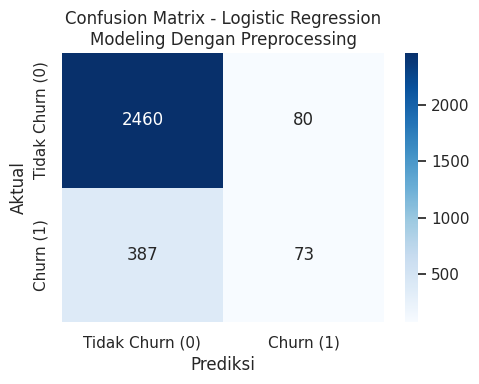


################################################################################
Training Model Preprocessing: Random Forest
################################################################################
Hasil Evaluasi - Modeling Dengan Preprocessing - Random Forest
Accuracy : 0.8477
Precision: 0.508
Recall   : 0.2065
F1-Score : 0.2937

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2540
           1       0.51      0.21      0.29       460

    accuracy                           0.85      3000
   macro avg       0.69      0.59      0.60      3000
weighted avg       0.81      0.85      0.82      3000



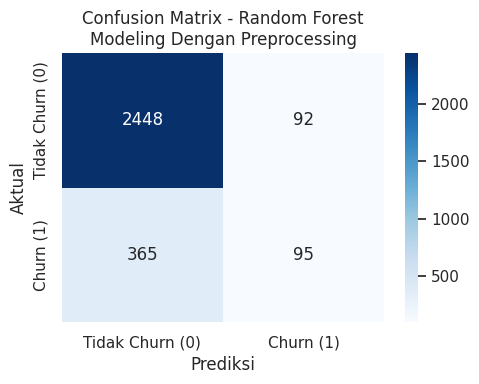


################################################################################
Training Model Preprocessing: Voting Classifier
################################################################################
Hasil Evaluasi - Modeling Dengan Preprocessing - Voting Classifier
Accuracy : 0.847
Precision: 0.504
Recall   : 0.137
F1-Score : 0.2154

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.50      0.14      0.22       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



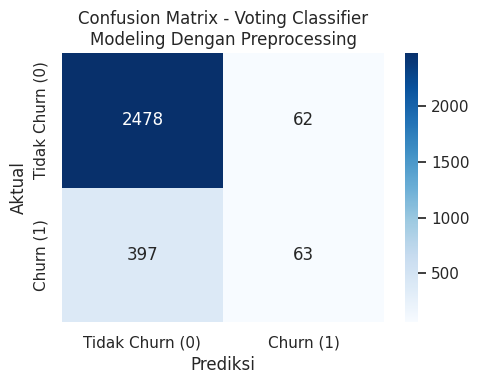

In [83]:
# ============================================================
# POIN 2.2.10 - TRAINING DAN EVALUASI MODEL PREPROCESSING
# ============================================================

preprocessing_predictions = {}

for model_name, model in preprocessing_models.items():
    print("\n" + "#" * 80)
    print(f"Training Model Preprocessing: {model_name}")
    print("#" * 80)

    model.fit(X_train_final, y_train_final)
    y_pred_prep = model.predict(X_test_final)

    preprocessing_predictions[model_name] = y_pred_prep

    evaluate_classification_model(
        model_name=model_name,
        scenario_name="Modeling Dengan Preprocessing",
        y_true=y_test_final,
        y_pred=y_pred_prep
    )


## 2.2.11 Ringkasan Hasil Modeling Dengan Preprocessing

Bagian ini menampilkan hasil evaluasi dari tiga model setelah data melalui tahap preprocessing.


In [84]:
# ============================================================
# POIN 2.2.11 - RINGKASAN HASIL MODELING DENGAN PREPROCESSING
# ============================================================

all_results_df = pd.DataFrame(evaluation_results)

preprocessing_results_df = all_results_df[
    all_results_df["Skenario"] == "Modeling Dengan Preprocessing"
]

display(preprocessing_results_df.sort_values(by="F1-Score", ascending=False))


,Skenario,Model,Accuracy,Precision,Recall,F1-Score
4,Modeling Dengan Preprocessing,Random Forest,0.847667,0.508021,0.206522,0.293663
3,Modeling Dengan Preprocessing,Logistic Regression,0.844333,0.477124,0.158696,0.238173
5,Modeling Dengan Preprocessing,Voting Classifier,0.847000,0.504000,0.136957,0.215385


# Perbandingan Sementara Direct Modeling dan Modeling Dengan Preprocessing

Bagian ini membandingkan hasil dari dua skenario yang sudah dikerjakan. Pada tahap berikutnya, hasil ini masih akan dilengkapi dengan skenario hyperparameter tuning sehingga total model menjadi 9 model.


,Skenario,Model,Accuracy,Precision,Recall,F1-Score
1,Direct Modeling,Random Forest,0.855333,0.536517,0.415217,0.468137
4,Modeling Dengan Preprocessing,Random Forest,0.847667,0.508021,0.206522,0.293663
3,Modeling Dengan Preprocessing,Logistic Regression,0.844333,0.477124,0.158696,0.238173
0,Direct Modeling,Logistic Regression,0.847667,0.510949,0.152174,0.234506
2,Direct Modeling,Voting Classifier,0.850000,0.543860,0.134783,0.216028
5,Modeling Dengan Preprocessing,Voting Classifier,0.847000,0.504000,0.136957,0.215385


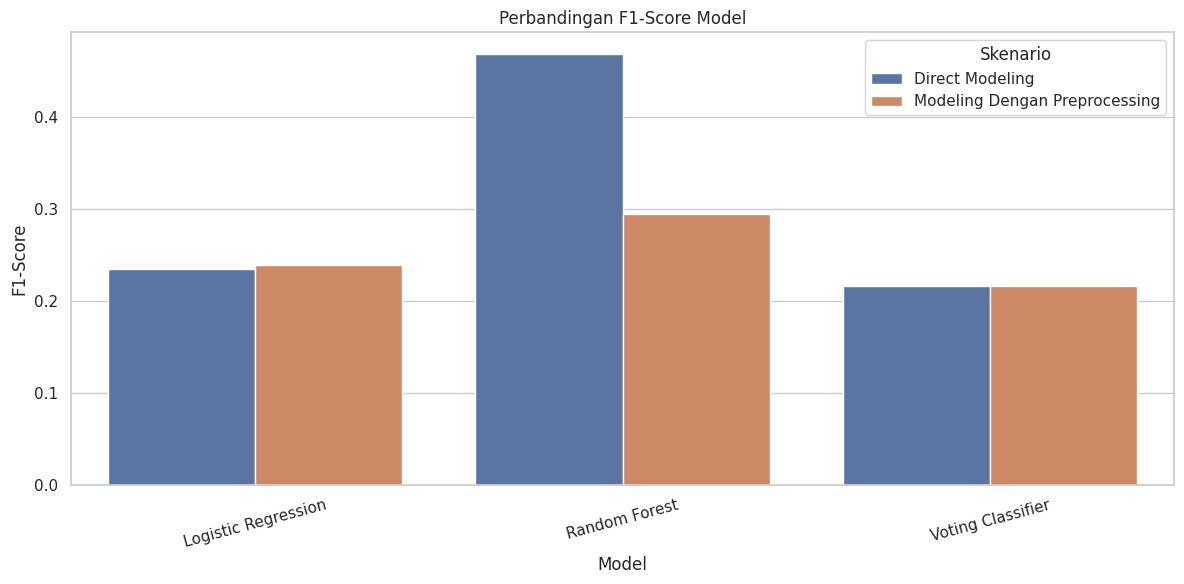

In [85]:
# ============================================================
# PERBANDINGAN SEMENTARA MODEL
# ============================================================

comparison_results_df = pd.DataFrame(evaluation_results)

display(
    comparison_results_df.sort_values(
        by=["F1-Score", "Accuracy"],
        ascending=False
    )
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_results_df,
    x="Model",
    y="F1-Score",
    hue="Skenario"
)
plt.title("Perbandingan F1-Score Model")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Kesimpulan Sementara Poin 2.1 dan 2.2

Bagian yang sudah diselesaikan pada tahap modeling adalah:

## 2.1 Direct Modeling
- Target `churn` sudah ditetapkan sebagai `y`.
- Fitur prediktor sudah ditetapkan sebagai `X`.
- Data sudah dibagi menjadi data latih dan data uji.
- Tiga model sudah dilatih, yaitu Logistic Regression, Random Forest, dan Voting Classifier.
- Setiap model sudah dievaluasi menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.

## 2.2 Modeling Dengan Preprocessing
- Missing value ditangani menggunakan imputer.
- Duplikasi data sudah dicek dan dihapus.
- Outlier ditangani menggunakan IQR capping.
- Fitur kategorikal diubah menggunakan OneHotEncoder.
- Fitur numerik di-scaling menggunakan StandardScaler setelah data splitting.
- Fitur yang kurang relevan sudah disesuaikan.
- Fitur prediktor dan target sudah ditetapkan kembali setelah preprocessing.
- Tiga model yang sama sudah dilatih ulang tanpa hyperparameter tuning.
- Setiap model sudah dievaluasi menggunakan metrik klasifikasi dan confusion matrix.

Tahap berikutnya adalah hyperparameter tuning dan feature selection untuk melengkapi skenario ketiga.


# Poin Penugasan 3 — Hyperparameter Tuning dan Feature Selection

Pada tahap ini dilakukan pengoptimalan model menggunakan data yang sudah melalui proses preprocessing.

Tahapan yang dilakukan pada bagian ini meliputi:

1. Melakukan analisis feature importance untuk melihat fitur yang paling berpengaruh terhadap prediksi churn.
2. Menyusun ruang pencarian hyperparameter untuk setiap model.
3. Melakukan hyperparameter tuning pada tiga model yang digunakan sebelumnya.
4. Mengambil best estimator dan best parameters dari hasil tuning.
5. Melatih kembali model dengan parameter terbaik.
6. Mengevaluasi performa model hasil tuning menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.

Model yang digunakan tetap mengikuti tiga kategori sebelumnya:
- Model konvensional: Logistic Regression
- Ensemble bagging: Random Forest
- Ensemble voting: Voting Classifier

# Poin Penugasan 3 — Hyperparameter Tuning dan Feature Selection

Pada tahap ini dilakukan pengoptimalan model menggunakan data yang sudah melalui proses preprocessing.

Tahapan yang dilakukan pada bagian ini meliputi:

1. Melakukan analisis feature importance untuk melihat fitur yang paling berpengaruh terhadap prediksi churn.
2. Menyusun ruang pencarian hyperparameter untuk setiap model.
3. Melakukan hyperparameter tuning pada tiga model yang digunakan sebelumnya.
4. Mengambil best estimator dan best parameters dari hasil tuning.
5. Melatih kembali model dengan parameter terbaik.
6. Mengevaluasi performa model hasil tuning menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.

Model yang digunakan tetap mengikuti tiga kategori sebelumnya:
- Model konvensional: Logistic Regression
- Ensemble bagging: Random Forest
- Ensemble voting: Voting Classifier

## 3.1 — Analisis Feature Importance

Feature importance digunakan untuk mengetahui fitur mana yang memiliki pengaruh paling besar terhadap prediksi churn.

Pada bagian ini digunakan Random Forest karena model ini dapat menghasilkan nilai feature importance secara langsung.

## 3.1 — Analisis Feature Importance

Feature importance digunakan untuk mengetahui fitur mana yang memiliki pengaruh paling besar terhadap prediksi churn.

Pada bagian ini digunakan Random Forest karena model ini dapat menghasilkan nilai feature importance secara langsung.

In [86]:
# ============================================================
# POIN 3.1 - ANALISIS FEATURE IMPORTANCE
# ============================================================

feature_importance_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

feature_importance_model.fit(X_train_final, y_train_final)

importance_df = pd.DataFrame({
    "Fitur": X_train_final.columns,
    "Importance": feature_importance_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("Top 20 fitur paling berpengaruh terhadap prediksi churn:")
display(importance_df.head(20))

Top 20 fitur paling berpengaruh terhadap prediksi churn:


,Fitur,Importance
7,total_spent,0.250016
13,satisfaction_score,0.235207
10,support_tickets,0.090044
16,lifetime_value,0.028089
3,avg_session_time,0.027989
15,marketing_spend_per_user,0.027380
8,avg_order_value,0.027288
4,pages_per_session,0.027082
20,days_since_last_purchase,0.026861
19,customer_tenure_days,0.026233


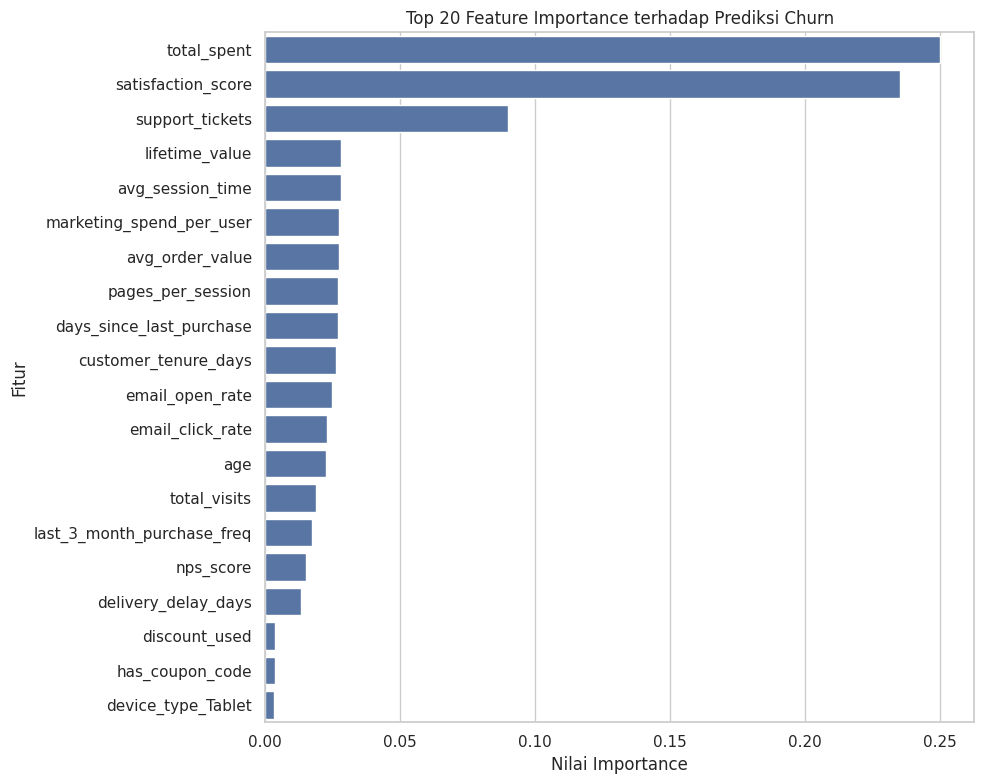

In [87]:
# ============================================================
# POIN 3.1 - VISUALISASI FEATURE IMPORTANCE
# ============================================================

top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Fitur"
)

plt.title("Top 20 Feature Importance terhadap Prediksi Churn")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## 3.2 — Menyiapkan Fungsi Evaluasi Model

Fungsi ini dibuat agar proses evaluasi setiap model memiliki format yang sama.

Metrik yang digunakan:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [88]:
# ============================================================
# POIN 3.2 - FUNGSI EVALUASI MODEL
# ============================================================

tuning_results = []

def evaluate_tuned_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    tuning_results.append({
        "Skenario": "Hyperparameter Tuning",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print("=" * 70)
    print(f"Hasil Evaluasi Model: {model_name}")
    print("=" * 70)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Tidak Churn (0)", "Churn (1)"],
        yticklabels=["Tidak Churn (0)", "Churn (1)"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

## 3.3 — Hyperparameter Tuning Model Konvensional: Logistic Regression

Logistic Regression digunakan sebagai model konvensional. Pada tahap tuning, beberapa parameter diuji untuk mencari konfigurasi yang memberikan performa terbaik.

In [89]:
# ============================================================
# POIN 3.3 - HYPERPARAMETER TUNING LOGISTIC REGRESSION
# ============================================================

logreg_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=2000
)

logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

logreg_grid = GridSearchCV(
    estimator=logreg_model,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

logreg_grid.fit(X_train_final, y_train_final)

best_logreg = logreg_grid.best_estimator_

print("Best Parameters Logistic Regression:")
print(logreg_grid.best_params_)

print("\nBest CV F1-Score Logistic Regression:")
print(logreg_grid.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Logistic Regression:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV F1-Score Logistic Regression:
0.47573972100604084


Hasil Evaluasi Model: Logistic Regression - Tuning
Accuracy : 0.7433333333333333
Precision: 0.34375
Recall   : 0.741304347826087
F1-Score : 0.4696969696969697

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83      2540
           1       0.34      0.74      0.47       460

    accuracy                           0.74      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.74      0.78      3000



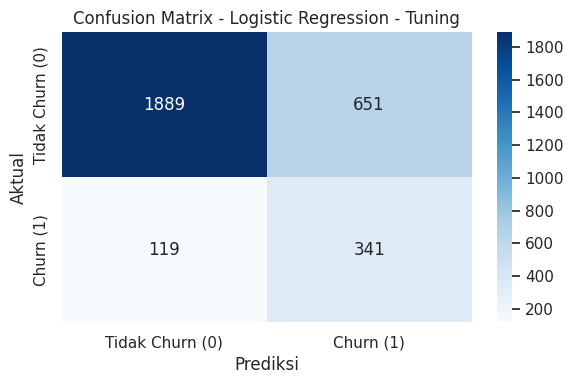

In [90]:
# ============================================================
# POIN 3.3 - EVALUASI LOGISTIC REGRESSION HASIL TUNING
# ============================================================

logreg_tuning_eval = evaluate_tuned_model(
    model_name="Logistic Regression - Tuning",
    model=best_logreg,
    X_test=X_test_final,
    y_test=y_test_final
)

## 3.4 — Hyperparameter Tuning Ensemble Bagging: Random Forest

Random Forest digunakan sebagai model ensemble bagging. Pada tahap tuning, dilakukan pencarian kombinasi parameter seperti jumlah pohon, kedalaman pohon, dan jumlah minimal sampel pada setiap percabangan.

In [91]:
# ============================================================
# POIN 3.4 - HYPERPARAMETER TUNING RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train_final, y_train_final)

best_rf = rf_random.best_estimator_

print("Best Parameters Random Forest:")
print(rf_random.best_params_)

print("\nBest CV F1-Score Random Forest:")
print(rf_random.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters Random Forest:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

Best CV F1-Score Random Forest:
0.645829814927423


Hasil Evaluasi Model: Random Forest - Tuning
Accuracy : 0.8556666666666667
Precision: 0.515358361774744
Recall   : 0.9847826086956522
F1-Score : 0.6766243465272591

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      2540
           1       0.52      0.98      0.68       460

    accuracy                           0.86      3000
   macro avg       0.76      0.91      0.79      3000
weighted avg       0.92      0.86      0.87      3000



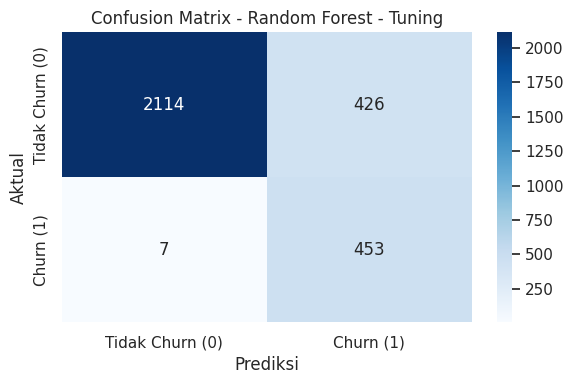

In [92]:
# ============================================================
# POIN 3.4 - EVALUASI RANDOM FOREST HASIL TUNING
# ============================================================

rf_tuning_eval = evaluate_tuned_model(
    model_name="Random Forest - Tuning",
    model=best_rf,
    X_test=X_test_final,
    y_test=y_test_final
)

## 3.5 — Hyperparameter Tuning Ensemble Voting: Voting Classifier

Voting Classifier digunakan sebagai model gabungan dari beberapa model konvensional.

Pada bagian ini model yang digabungkan adalah:
- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbors

Tuning dilakukan pada metode voting dan bobot masing-masing model.

In [93]:
# ============================================================
# POIN 3.5 - HYPERPARAMETER TUNING VOTING CLASSIFIER
# ============================================================

voting_base_logreg = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=2000
)

voting_base_svm = SVC(
    probability=True,
    random_state=42,
    class_weight="balanced"
)

voting_base_knn = KNeighborsClassifier()

voting_model = VotingClassifier(
    estimators=[
        ("lr", voting_base_logreg),
        ("svm", voting_base_svm),
        ("knn", voting_base_knn)
    ]
)

voting_param_grid = {
    "voting": ["soft"],
    "weights": [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [2, 2, 1],
        [2, 1, 2]
    ],
    "lr__C": [0.1, 1, 10],
    "svm__C": [0.1, 1, 10],
    "knn__n_neighbors": [3, 5, 7]
}

voting_random = RandomizedSearchCV(
    estimator=voting_model,
    param_distributions=voting_param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

voting_random.fit(X_train_final, y_train_final)

best_voting = voting_random.best_estimator_

print("Best Parameters Voting Classifier:")
print(voting_random.best_params_)

print("\nBest CV F1-Score Voting Classifier:")
print(voting_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Voting Classifier:
{'weights': [2, 1, 1], 'voting': 'soft', 'svm__C': 0.1, 'lr__C': 0.1, 'knn__n_neighbors': 5}

Best CV F1-Score Voting Classifier:
0.4748392526350574


Hasil Evaluasi Model: Voting Classifier - Tuning
Accuracy : 0.8363333333333334
Precision: 0.46637744034707157
Recall   : 0.4673913043478261
F1-Score : 0.46688382193268185

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2540
           1       0.47      0.47      0.47       460

    accuracy                           0.84      3000
   macro avg       0.68      0.69      0.69      3000
weighted avg       0.84      0.84      0.84      3000



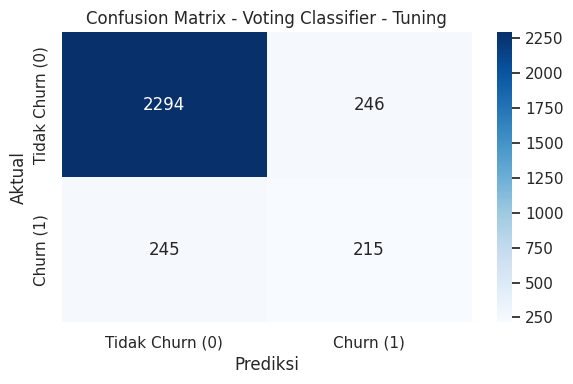

In [94]:
# ============================================================
# POIN 3.5 - EVALUASI VOTING CLASSIFIER HASIL TUNING
# ============================================================

voting_tuning_eval = evaluate_tuned_model(
    model_name="Voting Classifier - Tuning",
    model=best_voting,
    X_test=X_test_final,
    y_test=y_test_final
)

## 3.6 — Ringkasan Hasil Hyperparameter Tuning

Pada bagian ini seluruh hasil model tuning diringkas dalam satu tabel agar lebih mudah dibandingkan.

In [95]:
# ============================================================
# POIN 3.6 - RINGKASAN HASIL HYPERPARAMETER TUNING
# ============================================================

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="F1-Score",
    ascending=False
)

display(tuning_results_df)

,Skenario,Model,Accuracy,Precision,Recall,F1-Score
1,Hyperparameter Tuning,Random Forest - Tuning,0.855667,0.515358,0.984783,0.676624
0,Hyperparameter Tuning,Logistic Regression - Tuning,0.743333,0.343750,0.741304,0.469697
2,Hyperparameter Tuning,Voting Classifier - Tuning,0.836333,0.466377,0.467391,0.466884


## 3.7 — Menentukan Model Terbaik dari Hasil Tuning

Model terbaik sementara dipilih berdasarkan nilai F1-Score tertinggi. F1-Score digunakan karena metrik ini mempertimbangkan keseimbangan antara precision dan recall.

In [96]:
# ============================================================
# POIN 3.7 - MENENTUKAN MODEL TERBAIK HASIL TUNING
# ============================================================

best_tuning_row = tuning_results_df.iloc[0]
best_tuning_model_name = best_tuning_row["Model"]

if best_tuning_model_name == "Logistic Regression - Tuning":
    best_tuning_model = best_logreg
elif best_tuning_model_name == "Random Forest - Tuning":
    best_tuning_model = best_rf
elif best_tuning_model_name == "Voting Classifier - Tuning":
    best_tuning_model = best_voting
else:
    best_tuning_model = None

print("Model terbaik dari hasil hyperparameter tuning:")
print(best_tuning_model_name)

print("\nDetail performa:")
display(best_tuning_row)

Model terbaik dari hasil hyperparameter tuning:
Random Forest - Tuning

Detail performa:


,1
Skenario,Hyperparameter Tuning
Model,Random Forest - Tuning
Accuracy,0.855667
Precision,0.515358
Recall,0.984783
F1-Score,0.676624


## 3.8 — Menyimpan Model Terbaik Hasil Tuning

Model terbaik hasil tuning disimpan dalam format `.pkl`. File ini nantinya dapat digunakan kembali pada tahap deployment menggunakan Streamlit.

In [97]:
# ============================================================
# POIN 3.8 - MENYIMPAN MODEL TERBAIK HASIL TUNING
# ============================================================

MODEL_PATH = "best_tuning_model.pkl"

joblib.dump(best_tuning_model, MODEL_PATH)

print(f"Model terbaik berhasil disimpan sebagai: {MODEL_PATH}")

Model terbaik berhasil disimpan sebagai: best_tuning_model.pkl


## 3.9 — Kesimpulan Poin Penugasan 3

Berdasarkan proses hyperparameter tuning yang telah dilakukan, diperoleh tiga model hasil optimasi:

1. Logistic Regression hasil tuning
2. Random Forest hasil tuning
3. Voting Classifier hasil tuning

Setiap model telah dievaluasi menggunakan:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Model terbaik sementara dipilih berdasarkan nilai F1-Score tertinggi karena metrik ini dapat menunjukkan keseimbangan antara kemampuan model dalam memprediksi pelanggan churn dan tidak churn.

Model terbaik hasil tuning juga telah disimpan dalam file `.pkl` sehingga dapat digunakan kembali pada tahap deployment.